# **Instalación y carga**

In [3]:
!pip install rdflib nltk pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 615.4/615.4 kB 6.2 MB/s eta 0:00:00


In [4]:
import nltk
import pandas as pd

from rdflib import Graph, RDF, RDFS, OWL
from nltk.corpus import wordnet

In [5]:
nltk.download("wordnet")
nltk.download("omw-1.4")
nltk.download("extended_omw")

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package extended_omw to /root/nltk_data...


True

In [6]:
from google.colab import files

uploaded = files.upload()

KeyboardInterrupt: 

# **1. Leer el archivo OWL generado por Protegé**



In [7]:
g = Graph()

g.parse("ontologia_ciclo_conflicto_base.owl", format="xml")

print("Tripletas:", len(g))

Tripletas: 9973


Se identificaron en la ontología  9973 entidades con su relación de concepto.

**2. Extraer las clases ontológicas, Obtener nombre de cada clase**

In [8]:
def get_local_name(uri):
    uri = str(uri)

    if "#" in uri:
        return uri.split("#")[-1]

    return uri.rstrip("/").split("/")[-1]

In [10]:
classes = []

for cls in g.subjects(RDF.type, OWL.Class):

    uri = str(cls)

    label = g.value(
        cls,
        RDFS.label
    )

    classes.append({
        "owl_uri": uri,
        "owl_concept": get_local_name(uri),
        "label": str(label) if label else None
    })

print("Número de clases:", len(classes))

Número de clases: 2968


Se identificaron en total 2968 clases entre clases y subclases de la ontología

In [11]:
print(classes[:90])

[{'owl_uri': 'http://www.semanticweb.org/tesauro-cev-ciclo-conflicto#EstructuraArmada', 'owl_concept': 'EstructuraArmada', 'label': 'Estructuras armadas'}, {'owl_uri': 'http://www.semanticweb.org/tesauro-cev-ciclo-conflicto#Hecho_victimizante', 'owl_concept': 'Hecho_victimizante', 'label': 'Hecho victimizante'}, {'owl_uri': 'http://www.semanticweb.org/tesauro-cev-ciclo-conflicto#Arma', 'owl_concept': 'Arma', 'label': 'Armas'}, {'owl_uri': 'http://www.semanticweb.org/tesauro-cev-ciclo-conflicto#ProfesionOficio', 'owl_concept': 'ProfesionOficio', 'label': 'Profesiones y oficios'}, {'owl_uri': 'http://www.semanticweb.org/tesauro-cev-ciclo-conflicto#PartidosYMovimientosPoliticos', 'owl_concept': 'PartidosYMovimientosPoliticos', 'label': 'Partidos y movimientos políticos'}, {'owl_uri': 'http://www.semanticweb.org/tesauro-cev-ciclo-conflicto#APILAS', 'owl_concept': 'APILAS', 'label': 'APILAS'}, {'owl_uri': 'http://www.semanticweb.org/tesauro-cev-ciclo-conflicto#Misil_antitanqueta', 'owl_conc

**3. Normalizar nombres**

    Normaliza el nombre de una clase de la ontología para poder utilizarlo como término de búsqueda en WordNet.
    

In [12]:
import re

def normalize_term(term):

    # Convertir URI/local name a string
    term = str(term).strip()

    # Separar palabras escritas en CamelCase
    term = re.sub(
        r'(?<=[a-záéíóúñ])(?=[A-ZÁÉÍÓÚÑ])',
        ' ',
        term
    )

    # Separar secuencias como XMLParser -> XML Parser
    term = re.sub(
        r'(?<=[A-ZÁÉÍÓÚÑ])(?=[A-ZÁÉÍÓÚÑ][a-záéíóúñ])',
        ' ',
        term
    )

    # Reemplazar guiones bajos y guiones
    term = term.replace("_", " ")
    term = term.replace("-", " ")

    # Convertir a minúsculas
    term = term.lower()

    # Eliminar espacios duplicados
    term = re.sub(r'\s+', ' ', term).strip()

    return term

**4. Obtener sinsets**
Busca un término en WordNet en español.

    Prueba:
    1. El término con espacios.
    2. El término con guiones bajos.

    Retorna:
    - synsets encontrados
    - forma utilizada para la búsqueda


In [13]:
def get_synsets(term):


    term = normalize_term(term)

    # Formas posibles de búsqueda
    search_terms = [term]

    if " " in term:
        search_terms.append(term.replace(" ", "_"))

    for search_term in search_terms:

        synsets = wordnet.synsets(
            search_term,
            lang="spa"
        )

        if synsets:
            return synsets, search_term

    return [], None

In [14]:
def get_candidate_synsets(term):


    term = normalize_term(term)

    search_terms = [term]

    if " " in term:
        search_terms.append(term.replace(" ", "_"))

    candidates = []

    for search_term in search_terms:

        synsets = wordnet.synsets(
            search_term,
            lang="spa"
        )

        for syn in synsets:

            candidates.append(
                (syn, search_term)
            )

    # Eliminar duplicados
    unique_candidates = {}

    for syn, search_term in candidates:

        key = syn.name()

        if key not in unique_candidates:
            unique_candidates[key] = (
                syn,
                search_term
            )

    return list(unique_candidates.values())

In [15]:
concept_data = []

for concept in classes:

    synsets, search_term = get_synsets(concept["label"])

    if(len(synsets) > 0):
      print("=" * 60)
      print("Término:", search_term)
      print("Búsqueda utilizada:", search_term)
      print("Synsets encontrados:", len(synsets))
    concept_data.append({
        "owl_concept": concept["owl_concept"],
        "owl_uri" : concept["owl_uri"],
        "label" : concept["label"],
        "search_term": search_term,
        "wordnet_found": len(synsets) > 0,
        "num_synsets": len(synsets),
        "synsets": synsets
    })

concepts_df = pd.DataFrame(concept_data)

Término: acoso_sexual
Búsqueda utilizada: acoso_sexual
Synsets encontrados: 1
Término: batallón
Búsqueda utilizada: batallón
Synsets encontrados: 1
Término: unidad_militar
Búsqueda utilizada: unidad_militar
Synsets encontrados: 1
Término: unidad
Búsqueda utilizada: unidad
Synsets encontrados: 11
Término: brigada
Búsqueda utilizada: brigada
Synsets encontrados: 1
Término: división
Búsqueda utilizada: división
Synsets encontrados: 9
Término: compañía
Búsqueda utilizada: compañía
Synsets encontrados: 5
Término: cordillera
Búsqueda utilizada: cordillera
Synsets encontrados: 1
Término: cuchillo
Búsqueda utilizada: cuchillo
Synsets encontrados: 2
Término: democracia
Búsqueda utilizada: democracia
Synsets encontrados: 2
Término: homicidio
Búsqueda utilizada: homicidio
Synsets encontrados: 1
Término: espada
Búsqueda utilizada: espada
Synsets encontrados: 2
Término: exilio
Búsqueda utilizada: exilio
Synsets encontrados: 1
Término: medios
Búsqueda utilizada: medios
Synsets encontrados: 1
Término

In [16]:
concepts_df.head()

,owl_concept,owl_uri,label,search_term,wordnet_found,num_synsets,synsets
0,EstructuraArmada,http://www.semanticweb.org/tesauro-cev-ciclo-c...,Estructuras armadas,None,False,0,[]
1,Hecho_victimizante,http://www.semanticweb.org/tesauro-cev-ciclo-c...,Hecho victimizante,None,False,0,[]
2,Arma,http://www.semanticweb.org/tesauro-cev-ciclo-c...,Armas,None,False,0,[]
3,ProfesionOficio,http://www.semanticweb.org/tesauro-cev-ciclo-c...,Profesiones y oficios,None,False,0,[]
4,PartidosYMovimientosPoliticos,http://www.semanticweb.org/tesauro-cev-ciclo-c...,Partidos y movimientos políticos,None,False,0,[]


In [17]:
concepts_with_synsets = [
    item for item in concept_data
    if item["synsets"]
]

print(len(concepts_df))
print(len(concepts_with_synsets))


2968
189


In [18]:
concepts_with_synsets = concepts_df[
    concepts_df["wordnet_found"] == True
].copy()

print("Conceptos encontrados:", len(concepts_with_synsets))

Conceptos encontrados: 189


In [19]:
concepts_with_synsets[
    ["label", "num_synsets"]
].sort_values(
    "num_synsets",
    ascending=False
).head(20)

,label,num_synsets
360,Unidad,11
399,División,9
2180,Director,9
2387,Profesional,9
2058,Agente,8
2458,Trabajador,8
2465,Técnico,7
2212,Escolta,6
2332,Médico,6
2273,Jefe,6


De los 2968 conceptos, se encontró en wordnet synsets para 189, la mayoria de ellos asociados a profesiones, por lo cual escogimos este grupo en la ontología inicial, sin embargo, los términos de mayor frecuencia de synsets corresponden a dos términos que en general son objetos pero que tambien tienen una base en adjetivo (unidad y división).


In [20]:
def synset_terms(syn):
    """
    Obtiene los términos disponibles en español
    para un synset.
    """

    return syn.lemma_names(lang="spa")

**5. Se crean las funciones para determinar las relaciones entre los synsets**

In [21]:
def add_relation(
    relations,
    source_syn,
    relation_type,
    target_syn
):

    relations.append({
        "relation": relation_type,
        "source_synset": source_syn.name(),
        "source_definition": source_syn.definition(),
        "target_synset": target_syn.name(),
        "target_terms": synset_terms(target_syn),
        "target_definition": target_syn.definition()
    })

In [22]:
def get_wordnet_relations(syn):

    relations = []

    # ==========================================================
    # 1. SINONIMIA
    # ==========================================================

    spanish_lemmas = syn.lemma_names(lang="spa")

    if spanish_lemmas:

        relations.append({
            "relation": "synonymy",
            "source_synset": syn.name(),
            "source_definition": syn.definition(),
            "target_synset": syn.name(),
            "target_terms": spanish_lemmas,
            "target_definition": syn.definition()
        })

    # ==========================================================
    # 2. ANTONIMIA
    # ==========================================================

    for lemma in syn.lemmas(lang="spa"):

        for antonym in lemma.antonyms():

            relations.append({
                "relation": "antonymy",
                "source_synset": syn.name(),
                "source_definition": syn.definition(),
                "target_synset": antonym.synset().name(),
                "target_terms": [antonym.name()],
                "target_definition": antonym.synset().definition()
            })

    # ==========================================================
    # 3. HIPERONIMIA
    # ==========================================================

    for hyper in syn.hypernyms():

        add_relation(
            relations,
            syn,
            "hypernymy",
            hyper
        )

    # ==========================================================
    # 4. HIPONIMIA
    # ==========================================================

    for hypo in syn.hyponyms():

        add_relation(
            relations,
            syn,
            "hyponymy",
            hypo
        )

    # ==========================================================
    # 5. MERONIMIA
    # ==========================================================

    meronyms = (
        syn.part_meronyms()
        + syn.substance_meronyms()
        + syn.member_meronyms()
    )

    for mero in meronyms:

        add_relation(
            relations,
            syn,
            "meronymy",
            mero
        )

    # ==========================================================
    # 6. HOLONIMIA
    # ==========================================================

    holonyms = (
        syn.part_holonyms()
        + syn.substance_holonyms()
        + syn.member_holonyms()
    )

    for holo in holonyms:

        add_relation(
            relations,
            syn,
            "holonymy",
            holo
        )

    # ==========================================================
    # 7. TROPONIMIA
    # ==========================================================

    if syn.pos() == "v":

        for tropo in syn.hyponyms():

            add_relation(
                relations,
                syn,
                "troponymy",
                tropo
            )

    # ==========================================================
    # 8. TÉRMINOS COORDINADOS
    # ==========================================================

    for hyper in syn.hypernyms():

        for sibling in hyper.hyponyms():

            if sibling != syn:

                add_relation(
                    relations,
                    syn,
                    "coordinate_term",
                    sibling
                )

    # ==========================================================
    # 9. DERIVACIÓN MORFOLÓGICA
    # ==========================================================

    for lemma in syn.lemmas(lang="spa"):

        for related in lemma.derivationally_related_forms():

            relations.append({
                "relation": "derivational_form",
                "source_synset": syn.name(),
                "source_definition": syn.definition(),
                "target_synset": related.synset().name(),
                "target_terms": [related.name()],
                "target_definition": related.synset().definition()
            })

    return relations

In [23]:
verb_concepts = []

for _, row in concepts_with_synsets.iterrows():

    for syn in row["synsets"]:

        if syn.pos() == "v":

            verb_concepts.append({
                "owl_concept": row["owl_concept"],
                "synset": syn.name(),
                "definition": syn.definition()
            })

verb_concepts_df = pd.DataFrame(verb_concepts)
print(len(verb_concepts_df))
verb_concepts_df.head(1000)

2


,owl_concept,synset,definition
0,Mensajero,page.v.02,work as a page
1,Presidente,chair.v.01,"act or preside as chair, as of an academic dep..."


Solo se encontraron 2 synset que podrían estar relacionados a formas de un verbo, son objetos

In [24]:
synset_data = []

for _, row in concepts_with_synsets.iterrows():

    for syn in row["synsets"]:

        synset_data.append({
            "owl_concept": row["owl_concept"],
            "label": row["label"],
            "synset": syn.name(),
            "definition": syn.definition(),
            "lemmas": syn.lemma_names(lang="spa"),
            "relations": get_wordnet_relations(syn)
        })

synsets_df = pd.DataFrame(synset_data)

In [25]:
print(len(synsets_df))
synsets_df.head(20)

414


,owl_concept,label,synset,definition,lemmas,relations
0,Acoso_sexual,Acoso sexual,sexual_harassment.n.01,unwelcome sexual behavior by a supervisor towa...,[acoso_sexual],"[{'relation': 'synonymy', 'source_synset': 'se..."
1,Batallon,Batallón,battalion.n.02,a large indefinite number,"[batallón, ejército, masa, multitud]","[{'relation': 'synonymy', 'source_synset': 'ba..."
2,Unidad_militar,Unidad militar,military_unit.n.01,a unit that is part of some military service,"[unidad, unidad_militar]","[{'relation': 'synonymy', 'source_synset': 'mi..."
3,Unidad,Unidad,whole.n.02,an assemblage of parts that is regarded as a s...,"[conjunto, unidad, unidad_completa]","[{'relation': 'synonymy', 'source_synset': 'wh..."
4,Unidad,Unidad,drive.n.10,(computer science) a device that writes data o...,[unidad],"[{'relation': 'synonymy', 'source_synset': 'dr..."
5,Unidad,Unidad,system.n.01,instrumentality that combines interrelated int...,"[sistema, unidad]","[{'relation': 'synonymy', 'source_synset': 'sy..."
6,Unidad,Unidad,oneness.n.01,the quality of being united into one,[unidad],"[{'relation': 'synonymy', 'source_synset': 'on..."
7,Unidad,Unidad,unit.n.04,a single undivided whole,[unidad],"[{'relation': 'synonymy', 'source_synset': 'un..."
8,Unidad,Unidad,unit.n.03,an organization regarded as part of a larger s...,"[sección, unidad]","[{'relation': 'synonymy', 'source_synset': 'un..."
9,Unidad,Unidad,military_unit.n.01,a unit that is part of some military service,"[unidad, unidad_militar]","[{'relation': 'synonymy', 'source_synset': 'mi..."


In [26]:
relations_data = []

for _, row in synsets_df.iterrows():

    for relation in row["relations"]:

        relations_data.append({
            "owl_concept": row["owl_concept"],
            "label": row["label"],
            "source_synset": relation["source_synset"],
            "relation": relation["relation"],
            "target_synset": relation["target_synset"],
            "target_terms": ", ".join(relation["target_terms"]),
            "source_definition": relation["source_definition"],
            "target_definition": relation["target_definition"]
        })

relations_df = pd.DataFrame(relations_data)

relations_df.head(20)

,owl_concept,label,source_synset,relation,target_synset,target_terms,source_definition,target_definition
0,Acoso_sexual,Acoso sexual,sexual_harassment.n.01,synonymy,sexual_harassment.n.01,acoso_sexual,unwelcome sexual behavior by a supervisor towa...,unwelcome sexual behavior by a supervisor towa...
1,Acoso_sexual,Acoso sexual,sexual_harassment.n.01,hypernymy,harassment.n.02,,unwelcome sexual behavior by a supervisor towa...,the act of tormenting by continued persistent ...
2,Acoso_sexual,Acoso sexual,sexual_harassment.n.01,coordinate_term,badgering.n.01,,unwelcome sexual behavior by a supervisor towa...,the act of harassing someone
3,Acoso_sexual,Acoso sexual,sexual_harassment.n.01,coordinate_term,witch-hunt.n.01,caza_de_brujas,unwelcome sexual behavior by a supervisor towa...,searching out and harassing dissenters
4,Acoso_sexual,Acoso sexual,sexual_harassment.n.01,coordinate_term,tease.n.03,,unwelcome sexual behavior by a supervisor towa...,the act of harassing someone playfully or mali...
5,Acoso_sexual,Acoso sexual,sexual_harassment.n.01,coordinate_term,baiting.n.01,,unwelcome sexual behavior by a supervisor towa...,harassment especially of a tethered animal
6,Batallon,Batallón,battalion.n.02,synonymy,battalion.n.02,"batallón, ejército, masa, multitud",a large indefinite number,a large indefinite number
7,Batallon,Batallón,battalion.n.02,hypernymy,large_indefinite_quantity.n.01,,a large indefinite number,an indefinite quantity that is above the avera...
8,Batallon,Batallón,battalion.n.02,coordinate_term,busload.n.01,,a large indefinite number,the quantity of cargo or the number of passeng...
9,Batallon,Batallón,battalion.n.02,coordinate_term,much.n.01,,a large indefinite number,a great amount or extent


In [27]:
simple_relations_df = relations_df[
    [
        "owl_concept",
        "label",
        "relation",
        "target_synset",
        "target_terms"
    ]
].copy()

simple_relations_df

,owl_concept,label,relation,target_synset,target_terms
0,Acoso_sexual,Acoso sexual,synonymy,sexual_harassment.n.01,acoso_sexual
1,Acoso_sexual,Acoso sexual,hypernymy,harassment.n.02,
2,Acoso_sexual,Acoso sexual,coordinate_term,badgering.n.01,
3,Acoso_sexual,Acoso sexual,coordinate_term,witch-hunt.n.01,caza_de_brujas
4,Acoso_sexual,Acoso sexual,coordinate_term,tease.n.03,
...,...,...,...,...,...
11889,Gobernador,Gobernador,coordinate_term,achiever.n.01,éxito
11890,Gobernador,Gobernador,coordinate_term,elizabethan.n.01,
11891,Gobernador,Gobernador,coordinate_term,sex_object.n.01,
11892,Gobernador,Gobernador,coordinate_term,philosopher.n.02,


In [28]:
relation_summary = (
    relations_df
    .groupby(["label", "relation"])
    .size()
    .reset_index(name="count")
)

relation_summary

,label,relation,count
0,Abogado,coordinate_term,9
1,Abogado,holonymy,1
2,Abogado,hypernymy,1
3,Abogado,hyponymy,11
4,Abogado,synonymy,1
...,...,...,...
731,Vocero,hyponymy,4
732,Vocero,synonymy,1
733,Yesero,coordinate_term,64
734,Yesero,hypernymy,1


In [32]:
relations_df["relation"].value_counts()

,count
relation,
coordinate_term,9143
hyponymy,1861
synonymy,414
hypernymy,382
holonymy,35
meronymy,29
derivational_form,29
antonymy,1


In [35]:
top20 = (
    relations_df
    .groupby(["owl_concept", "label"])
    .size()
    .reset_index(name="num_relaciones")
    .sort_values("num_relaciones", ascending=False)
    .head(20)
)

display(top20)

,owl_concept,label,num_relaciones
177,Trabajador,Trabajador,673
95,Interprete,Intérprete,531
16,Artista,Artista,521
96,Investigador,Investigador,512
181,Unidad,Unidad,482
86,Gobernador,Gobernador,438
92,Ingeniero,Ingeniero,428
38,Cientifico,Científico,425
5,Agente,Agente,267
45,Conductor,Conductor,234


In [42]:
# Total de entidades por grupo
total_entidades = (
    classes_df
    .dropna(subset=["grupo"])
    .groupby("grupo")["owl_concept"]
    .nunique()
    .rename("cantidad_entidades")
)

# Entidades con al menos una relación
entidades_con_relacion = (
    relations_df
    .dropna(subset=["grupo"])
    .groupby("grupo")["owl_concept"]
    .nunique()
    .rename("entidades_con_relacion")
)

# Conteo de cada tipo de relación
conteo_tipos = (
    relations_df
    .dropna(subset=["grupo"])
    .groupby(["grupo", "relation"])
    .size()
    .unstack(fill_value=0)
)

# Unir resultados
tabla_resumen = pd.concat(
    [total_entidades, entidades_con_relacion, conteo_tipos],
    axis=1
).fillna(0)

# Porcentaje de entidades con relación
tabla_resumen["porcentaje_con_relacion"] = (
    tabla_resumen["entidades_con_relacion"]
    / tabla_resumen["cantidad_entidades"]
    * 100
).round(1)

# Relaciones que queremos mostrar
tipos = [
    "synonymy",
    "hyponymy",
    "hypernymy",
    "holonymy",
    "meronymy",
    "derivational_form",
    "antonymy"
]

# Si alguna no existe, crearla en cero
for tipo in tipos:
    if tipo not in tabla_resumen.columns:
        tabla_resumen[tipo] = 0

# Tabla final
columnas = [
    "cantidad_entidades",
    "entidades_con_relacion",
    "porcentaje_con_relacion"
] + tipos

tabla_final = tabla_resumen[columnas].reset_index()

tabla_final.columns = [
    "Grupo de ontología",
    "Cantidad de entidades",
    "Entidades con relación",
    "Entidades con relación (%)",
    "Sinonimia",
    "Hiponimia",
    "Hiperonimia",
    "Holonimia",
    "Meronimia",
    "Derivación morfológica",
    "Antonimia"
]

display(tabla_final)

,Grupo de ontología,Cantidad de entidades,Entidades con relación,Entidades con relación (%),Sinonimia,Hiponimia,Hiperonimia,Holonimia,Meronimia,Derivación morfológica,Antonimia
0,Armas,94,7,7.4,15,62,16,1,14,0,0
1,Estructuras armadas,1726,8,0.5,31,254,31,8,13,0,0
2,Hechos victimizantes,95,3,3.2,3,0,3,0,0,0,0
3,Partidos y movimientos políticos,111,1,0.9,1,0,1,0,1,0,0
4,Profesiones y oficios,942,170,18.0,364,1545,331,26,1,29,1


Del total (11894) de relaciones encontradas, el grupo con más relaciones fue estructuras armadas, seguido de profesiones y oficios y partidos y movimientos. Sin embargo, para profesiones y oficios, se encontro un mayor porcentaje de relaciones dentro de Wordnet. Especialmente relaciones de hiponimia, esto posiblemente relacionado a subcategorias dentro de algunas profesiones. Ademas fue en la única en donde identificamos un antónimo. Para estructuras armadas y armas se encontraron varias relaciones de meronimia (parte de)como caracteristicas de este tipo de objetos. Son pocas relaciones para partidos y para hechos, representando caracteristicas unicas y especificas de la ontologia que son dificil de asociar con thesaurus como Wordnet.



,grupo,owl_concept,label,num_relaciones
3,Armas,Mortero,Mortero,87
13,Estructuras armadas,Unidad,Unidad,482
17,Hechos victimizantes,Homicidio,Homicidio,19
18,Partidos y movimientos políticos,PartidoVerde,Partido Verde,36
179,Profesiones y oficios,Trabajador,Trabajador,673



Entidades seleccionadas:
Armas: Mortero (87 relaciones)
Estructuras armadas: Unidad (482 relaciones)
Hechos victimizantes: Homicidio (19 relaciones)
Partidos y movimientos políticos: Partido Verde (36 relaciones)
Profesiones y oficios: Trabajador (673 relaciones)


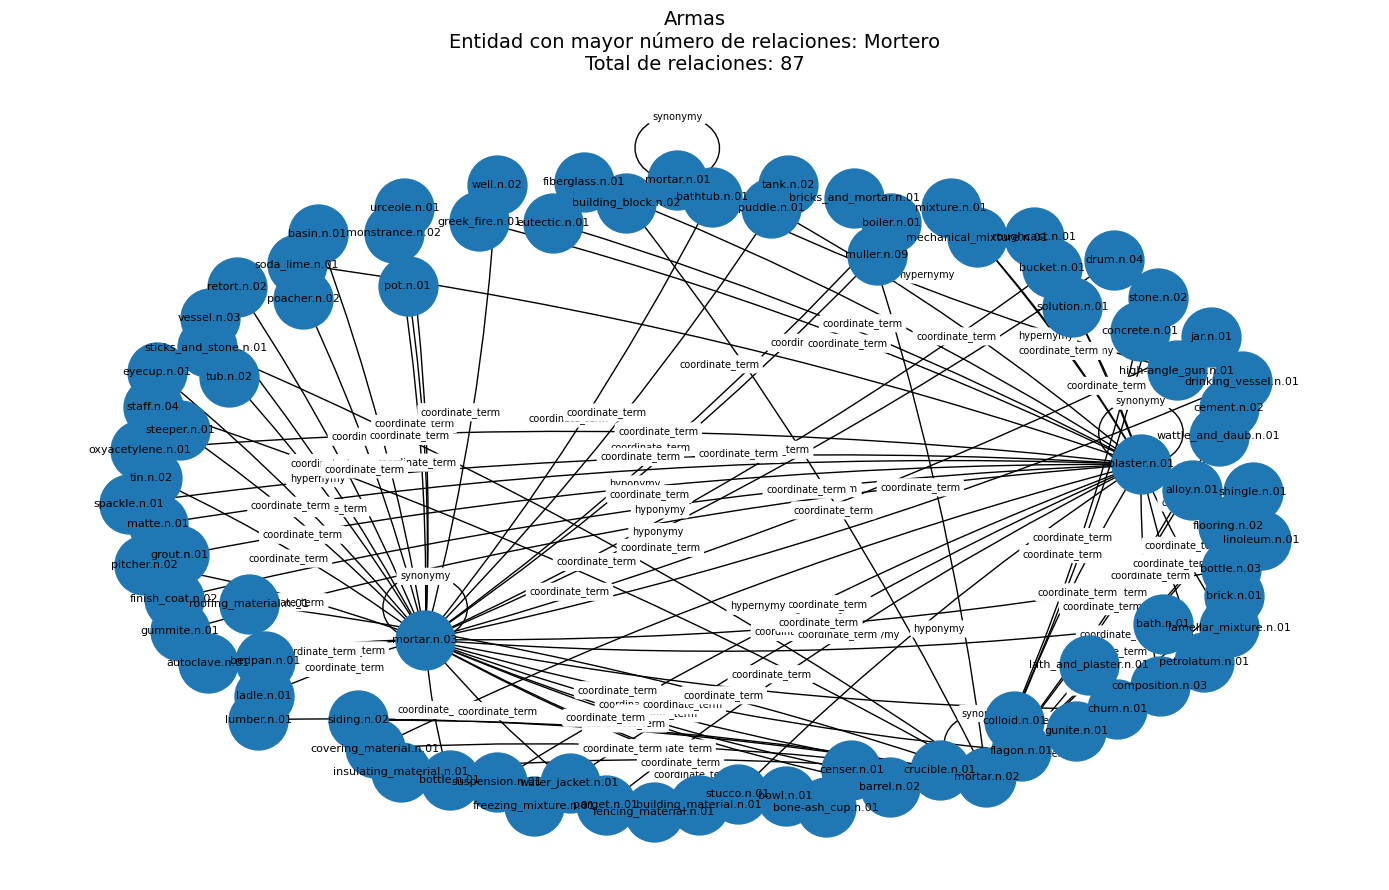

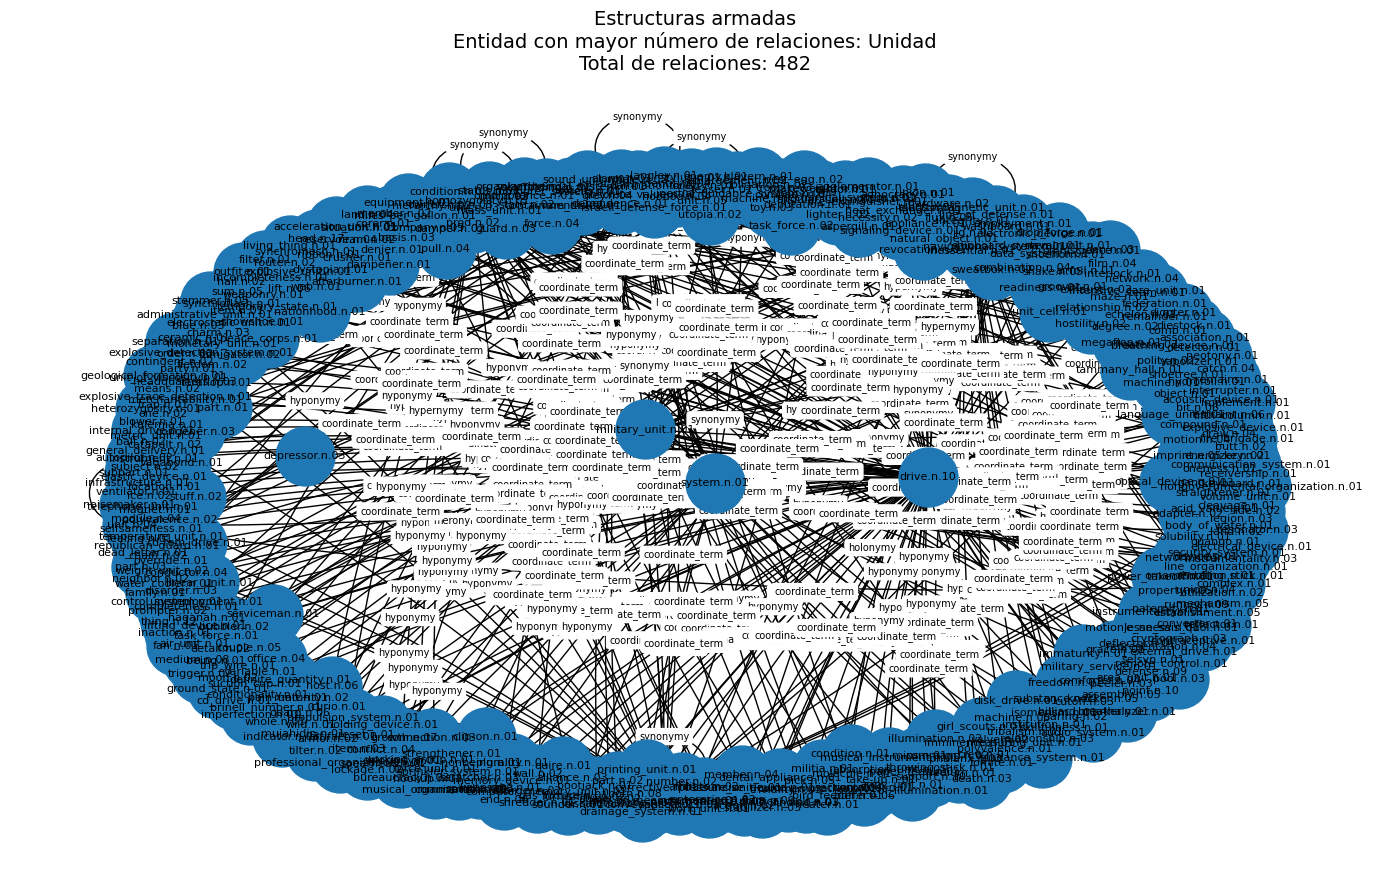

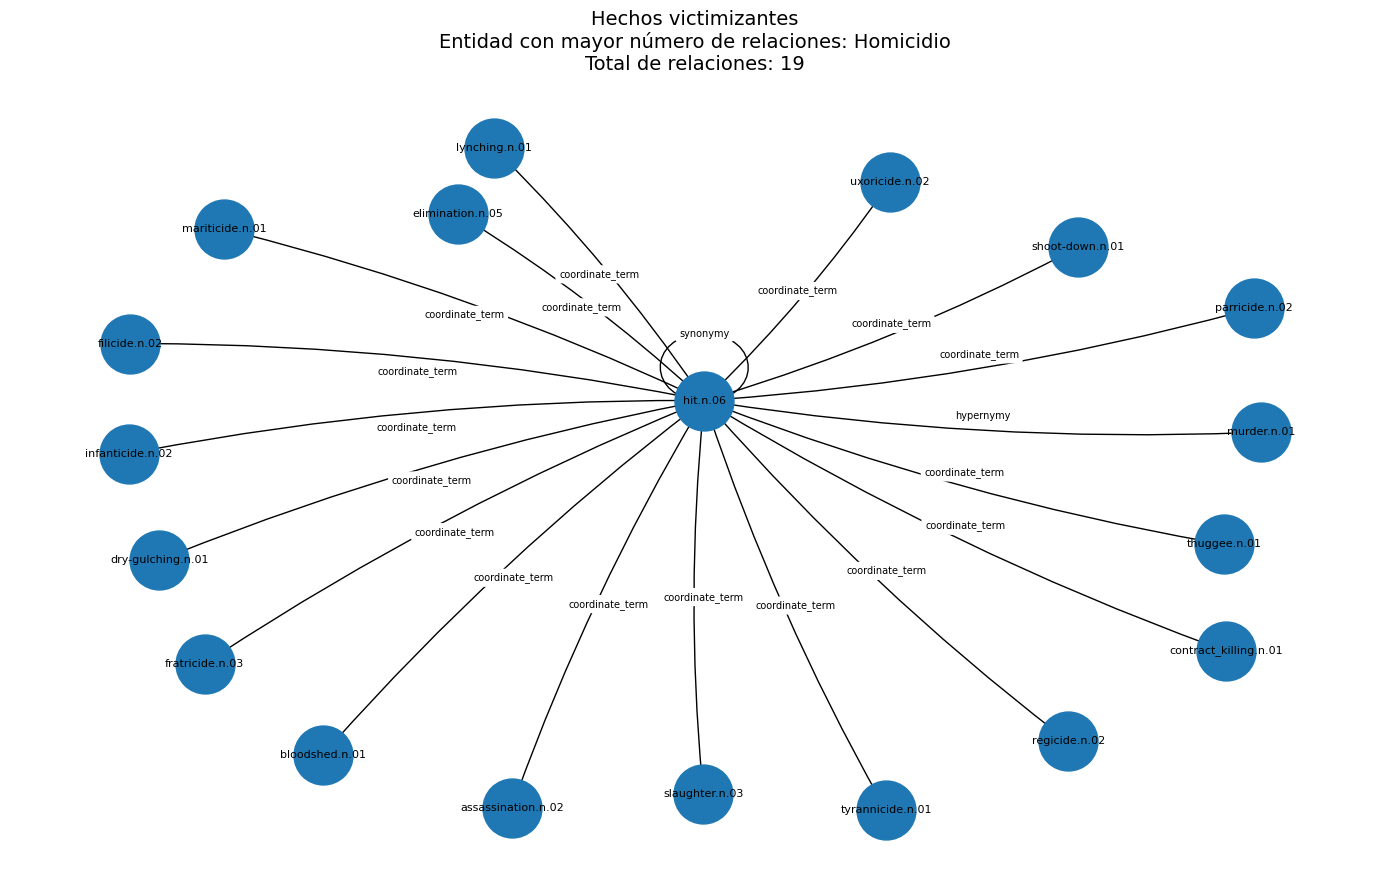

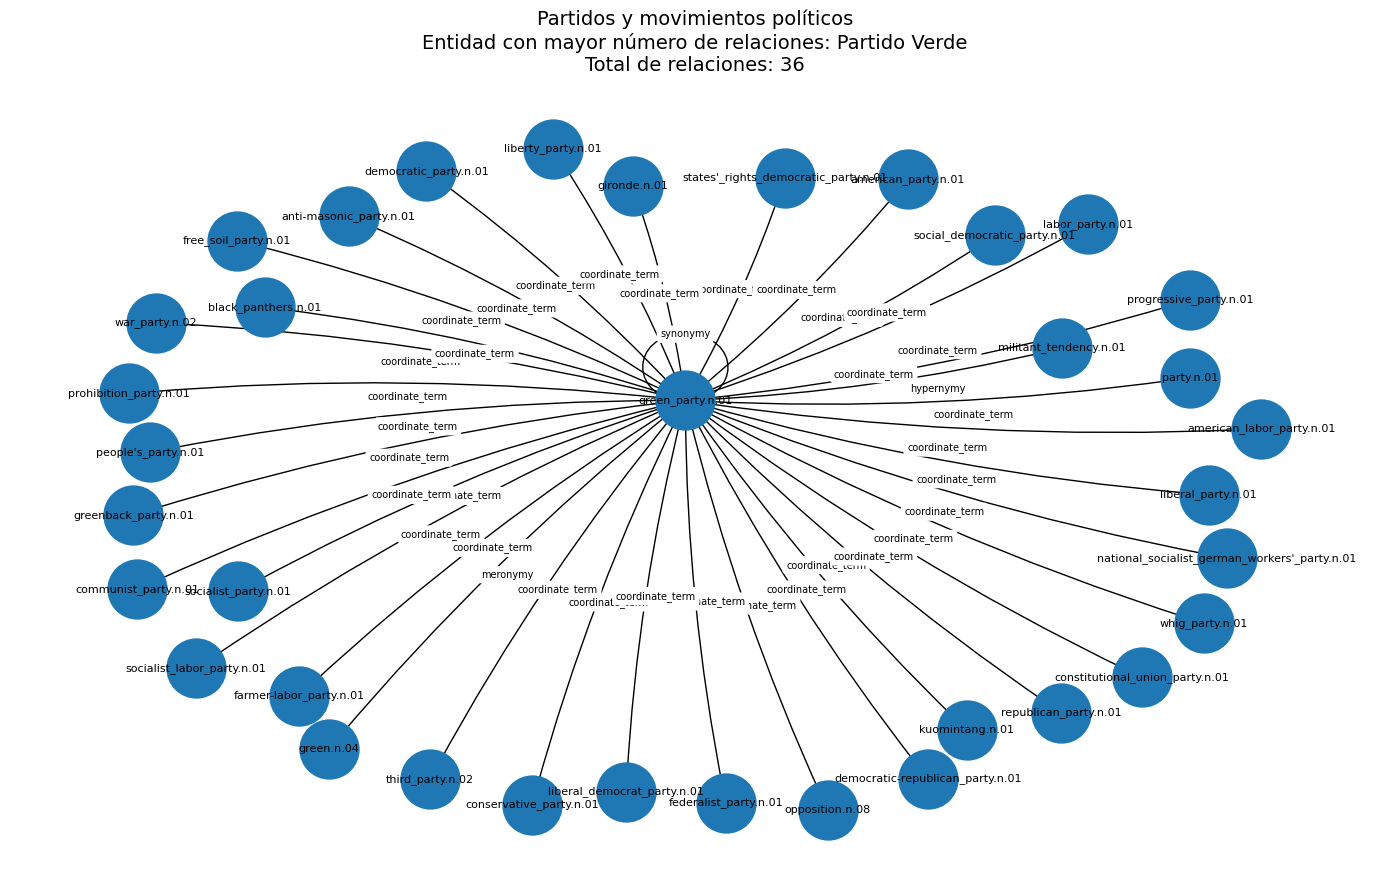

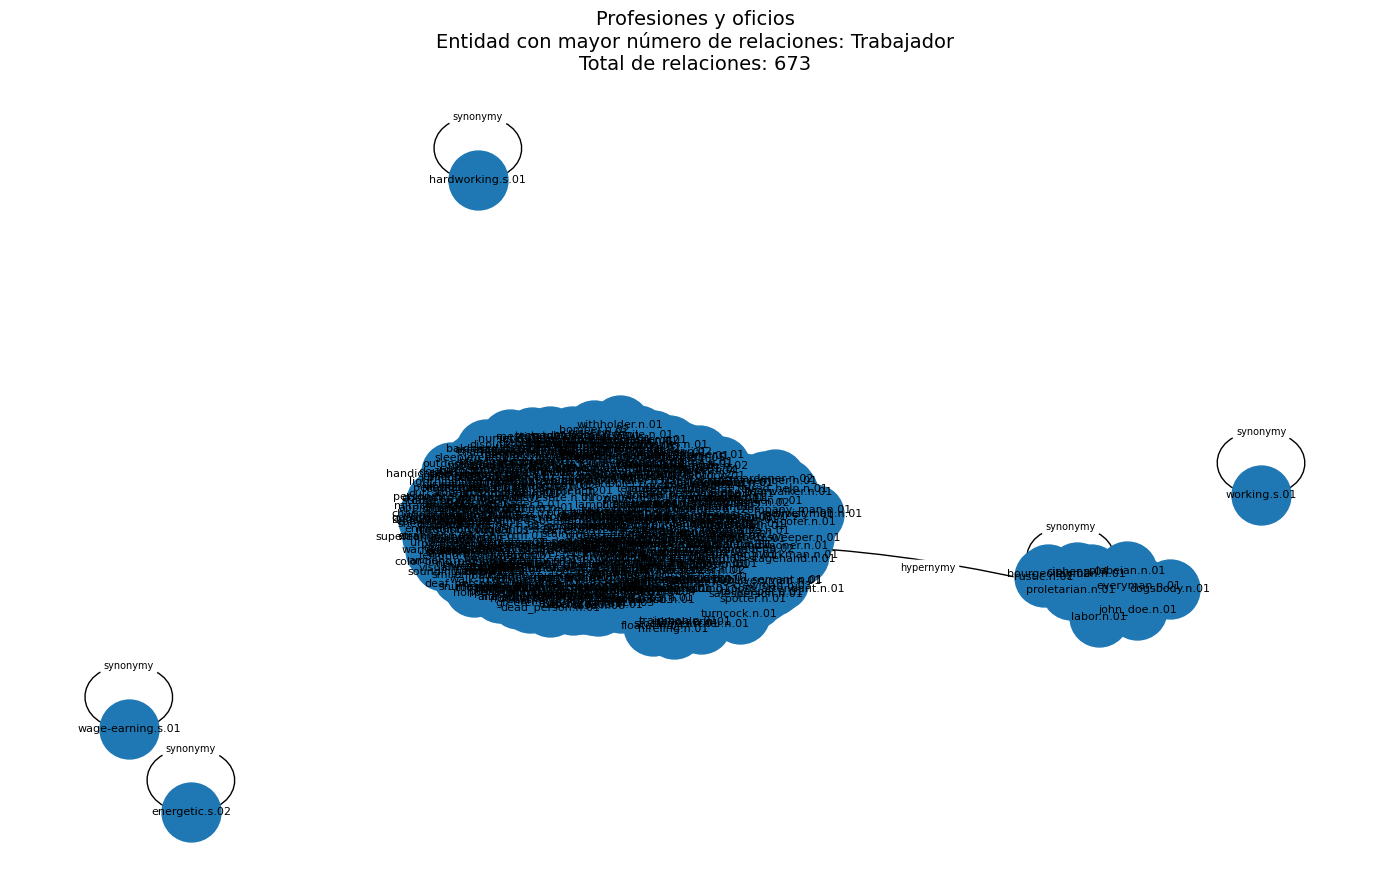

In [43]:
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd

# ============================================================
# 1. Seleccionar la entidad con más relaciones de cada grupo
# ============================================================

top_por_grupo = (
    relations_df
    .dropna(subset=["grupo"])
    .groupby(["grupo", "owl_concept", "label"])
    .size()
    .reset_index(name="num_relaciones")
    .sort_values(
        ["grupo", "num_relaciones"],
        ascending=[True, False]
    )
    .groupby("grupo")
    .head(1)
)

display(top_por_grupo)

# Lista de las 5 entidades seleccionadas
entidades_top = top_por_grupo["label"].tolist()

print("\nEntidades seleccionadas:")
for _, row in top_por_grupo.iterrows():
    print(
        f"{row['grupo']}: "
        f"{row['label']} "
        f"({row['num_relaciones']} relaciones)"
    )


# ============================================================
# 2. Graficar la entidad con más relaciones de cada grupo
# ============================================================

for _, entidad in top_por_grupo.iterrows():

    label = entidad["label"]
    grupo = entidad["grupo"]
    num_relaciones = entidad["num_relaciones"]

    G = nx.DiGraph()

    # Filtrar synsets correspondientes a esta entidad
    selected = synsets_df[
        synsets_df["label"] == label
    ]

    # --------------------------------------------------------
    # Construcción del grafo
    # --------------------------------------------------------

    for _, row in selected.iterrows():

        source = row["synset"]

        # Nodo central
        G.add_node(
            source,
            node_type="source"
        )

        # Agregar relaciones
        for relation in row["relations"]:

            target = relation["target_synset"]
            relation_type = relation["relation"]

            G.add_node(
                target,
                node_type="target"
            )

            G.add_edge(
                source,
                target,
                relation=relation_type
            )

    # Si no hay relaciones, no graficar
    if G.number_of_edges() == 0:
        print(f"Sin relaciones para: {label}")
        continue

    # ========================================================
    # 3. GRAFICAR
    # ========================================================

    plt.figure(figsize=(14, 9))

    pos = nx.spring_layout(
        G,
        seed=42,
        k=2.5
    )

    # Separar nodo central y nodos relacionados
    source_nodes = [
        n for n, d in G.nodes(data=True)
        if d.get("node_type") == "source"
    ]

    target_nodes = [
        n for n, d in G.nodes(data=True)
        if d.get("node_type") == "target"
    ]

    # Nodo central más grande
    nx.draw_networkx_nodes(
        G,
        pos,
        nodelist=source_nodes,
        node_size=3500
    )

    # Nodos relacionados
    nx.draw_networkx_nodes(
        G,
        pos,
        nodelist=target_nodes,
        node_size=1800
    )

    # Flechas
    nx.draw_networkx_edges(
        G,
        pos,
        arrows=True,
        arrowsize=18,
        connectionstyle="arc3,rad=0.05"
    )

    # Etiquetas de nodos
    nx.draw_networkx_labels(
        G,
        pos,
        font_size=8
    )

    # Etiquetas de relaciones
    edge_labels = nx.get_edge_attributes(
        G,
        "relation"
    )

    nx.draw_networkx_edge_labels(
        G,
        pos,
        edge_labels=edge_labels,
        font_size=7,
        rotate=False
    )

    plt.title(
        f"{grupo}\n"
        f"Entidad con mayor número de relaciones: {label}\n"
        f"Total de relaciones: {num_relaciones}",
        fontsize=14
    )

    plt.axis("off")
    plt.tight_layout()
    plt.show()

Se represntan las relaciones para la entidad con mas relaciones en cada grupo, llama la atención la palabra trabajador, con multiples relaciones de hiperonimia (clase superior) pero tambien como adjetivo (que trabaja mucho) y como forma de una verbo (trabajar), lo que indica la determinación con los lemmas para establecer las relaciones.

## **NOTA FINAL**
**Sobre escogencia de los grupos: **
Teniendo en cuenta la ontología escogimos 5 grupos a discreción de cada integrante para representar:
1. La diversidad de los grupos principales de la ontología, objetos directos como armas y profesiones vs entidades elaboradas como hechos victimizantes. y en principio, la capacidad de extrapolarse a Wordnet.
2. Grupos en los que las relaciones podrían determinarse dificil como hechos y partidos, de donde se observa finalmente la extracción de palabras de cada objeto compuesto para establecer los synsets.
3. Se tuvo en cuenta un componente jerarquico que creimos inicialmente util para terminos como hiperonimia o hiponimia en caso de extraer entidades para relaciones desde la misma ontologia.

**Sobre el ejercicio de relaciones: **
Derivado de la observación de la ontologia raiz, y los grafos observados al crear la ontologia en Protegé, detectamos que podría determinarse una dificultad para algunos de ellos en encontrar relaciones.
A pesar de esto, encontramos que el thesaurus WORDNET se comportó mejor de los esperado en la identificación de synsets, a pesar de la especialización en términologia y en contexto de la ontologia base.
Tambien como era de esperarse, el grupo con entidades mas generalizables (profesiones)fue en el que mas encontramos relaciones y todo tipo de relaciones, ya que muchos tenian una representación en wordnet y por ende acceso a todas las relaciones a buscar.

# 4. Consultas SPARQL sobre la ontología

Esta sección implementa el punto 4 del taller: consultas SPARQL sobre la ontología del ciclo del conflicto armado construida en Protégé (`ontologia_ciclo_conflicto_base.owl`). Se instala `rdflib`, se carga y parsea el archivo OWL, y se ejecutan las 13 consultas documentadas en la bitácora sobre el mismo `Graph` `g`.

In [11]:
!pip install rdflib -q

In [ ]:
try:
    from google.colab import files
    uploaded = files.upload()  # subir ontologia_ciclo_conflicto_base.owl
    owl_path = "ontologia_ciclo_conflicto_base.owl"
except ImportError:
    owl_path = "02-ontologia-ciclo-conflicto/ontologia_ciclo_conflicto_base.owl"

In [13]:
from rdflib import Graph

g = Graph()
g.parse(owl_path, format="xml")
print(len(g))  # tripletas cargadas, debe imprimir 9973

9973


In [14]:
# Consulta 1. Armas: subclases directas de Arma
query_1 = """
PREFIX : <http://www.semanticweb.org/tesauro-cev-ciclo-conflicto#>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
SELECT ?arma ?label WHERE {
  ?arma rdfs:subClassOf :Arma .
  OPTIONAL { ?arma rdfs:label ?label . }
} ORDER BY ?arma
"""

results = list(g.query(query_1))
print(f"Resultados: {len(results)}")
for row in results[:10]:
    valores_limpios = []
    for valor in row:
        if valor is None:
            continue
        texto = str(valor).split("#")[-1]
        valores_limpios.append(texto)
    if len(valores_limpios) == 2:
        print(f" - {valores_limpios[0]} → '{valores_limpios[1]}'")
    else:
        print(" -", " | ".join(valores_limpios))

Resultados: 2
 - Instrumentos → 'Instrumentos'
 - Medios → 'Medios'


**Consulta 2. Armas**

Propósito: recupera todas las especializaciones de armas de fuego, incluidas las que aparecen a cualquier profundidad.

In [15]:
query_2 = """
PREFIX : <http://www.semanticweb.org/tesauro-cev-ciclo-conflicto#>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
SELECT ?arma ?label WHERE {
  ?arma rdfs:subClassOf+ :Armas_de_fuego .
  OPTIONAL { ?arma rdfs:label ?label . }
} ORDER BY ?arma
"""

results_2 = list(g.query(query_2))
print(f"Resultados: {len(results_2)}")
for row in results_2[:10]:
    valores_limpios = []
    for valor in row:
        if valor is None:
            continue
        texto = str(valor).split("#")[-1]
        valores_limpios.append(texto)
    if len(valores_limpios) == 2:
        print(f" - {valores_limpios[0]} → '{valores_limpios[1]}'")
    else:
        print(" -", " | ".join(valores_limpios))

Resultados: 77
 - APILAS → 'APILAS'
 - Accuracy_International_L96 → 'Accuracy International L96'
 - Ametralladora_GAU_17A → 'Ametralladora GAU-17A'
 - Ametralladora_M240 → 'Ametralladora M240'
 - Ametralladora_M249_SAW → 'Ametralladora M249 SAW'
 - Ametralladora_M2HB → 'Ametralladora M2HB'
 - Ametralladora_M60 → 'Ametralladora M60'
 - Ametralladora_Vektor_SS_77 → 'Ametralladora Vektor SS-77'
 - Ametralladora_ligera → 'Ametralladora ligera'
 - Ametralladora_media → 'Ametralladora media'


**Consulta 3. Armas**

Propósito: busca las estructuras armadas y las armas que usan; queda preparada para el poblamiento de individuos (da 0 resultados hasta que existan individuos).

In [16]:
query_3 = """
PREFIX : <http://www.semanticweb.org/tesauro-cev-ciclo-conflicto#>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
SELECT ?estructura ?arma WHERE { ?estructura :usaArma ?arma . } ORDER BY ?estructura
"""

results_3 = list(g.query(query_3))
print(f"Resultados: {len(results_3)}")
for row in results_3[:10]:
    valores_limpios = []
    for valor in row:
        if valor is None:
            continue
        texto = str(valor).split("#")[-1]
        valores_limpios.append(texto)
    print(" -", " | ".join(valores_limpios))

Resultados: 0


**Consulta 4. Hechos victimizantes**

Propósito: lista las categorías hijas de Hechos victimizantes para inspeccionar los principales tipos de afectación.

In [17]:
query_4 = """
PREFIX : <http://www.semanticweb.org/tesauro-cev-ciclo-conflicto#>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
SELECT ?hecho ?label WHERE {
  ?hecho rdfs:subClassOf :Hecho_victimizante .
  OPTIONAL { ?hecho rdfs:label ?label . }
} ORDER BY ?hecho
"""

results_4 = list(g.query(query_4))
print(f"Resultados: {len(results_4)}")
for row in results_4[:10]:
    valores_limpios = []
    for valor in row:
        if valor is None:
            continue
        texto = str(valor).split("#")[-1]
        valores_limpios.append(texto)
    if len(valores_limpios) == 2:
        print(f" - {valores_limpios[0]} → '{valores_limpios[1]}'")
    else:
        print(" -", " | ".join(valores_limpios))

Resultados: 23
 - Amenaza_a_la_Vida → 'Amenaza a la Vida'
 - Ataque_a_bien_protegido → 'Ataque a bien protegido'
 - Ataque_indiscriminado → 'Ataque indiscriminado'
 - Atentado_al_derecho_a_la_vida → 'Atentado al derecho a la vida'
 - Confinamiento → 'Confinamiento'
 - Crímenes_de_guerra → 'Crímenes de guerra'
 - Crímenes_de_lesa_humanidad → 'Crímenes de lesa humanidad'
 - Desaparación_forzada → 'Desaparición forzada'
 - Desplazamiento_forzado → 'Desplazamiento forzado'
 - Despojo/abandono_de_tierras → 'Despojo/abandono de tierras'


**Consulta 5. Hechos victimizantes**

Propósito: recupera todas las subclases de Homicidio, como Masacre o Ejecución extrajudicial.

In [18]:
query_5 = """
PREFIX : <http://www.semanticweb.org/tesauro-cev-ciclo-conflicto#>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
SELECT ?hecho ?label WHERE {
  ?hecho rdfs:subClassOf+ :Homicidio .
  OPTIONAL { ?hecho rdfs:label ?label . }
} ORDER BY ?hecho
"""

results_5 = list(g.query(query_5))
print(f"Resultados: {len(results_5)}")
for row in results_5[:10]:
    valores_limpios = []
    for valor in row:
        if valor is None:
            continue
        texto = str(valor).split("#")[-1]
        valores_limpios.append(texto)
    if len(valores_limpios) == 2:
        print(f" - {valores_limpios[0]} → '{valores_limpios[1]}'")
    else:
        print(" -", " | ".join(valores_limpios))

Resultados: 11
 - Ejecucion_extrajudicial → 'Ejecucion extrajudicial'
 - Ejecución_arbitraria → 'Ejecución arbitraria'
 - Ejecución_extrajudicial_presentada_como_muerte_en_combate_o_falso_positivo → 'Ejecución extrajudicial presentada como muerte en combate o falso positivo'
 - Ejecución_sumaria → 'Ejecución sumaria'
 - Masacre → 'Masacre'
 - Muerte_de_civiles → 'Muerte de civiles'
 - Muerte_de_civiles_causada_por_ataques_a_bienes_civiles → 'Muerte de civiles causada por ataques a bienes civiles'
 - Muerte_de_civiles_en_atentados_con_bombas → 'Muerte de civiles en atentados con bombas'
 - Muerte_de_civiles_en_medio_de_combates → 'Muerte de civiles en medio de combates'
 - Muerte_de_civiles_por_activación_de_explosivos_o_minas → 'Muerte de civiles por activación de explosivos o minas'


**Consulta 6. Hechos victimizantes**

Propósito: recupera todos los tipos de amenazas.

In [28]:
query_6 = """
PREFIX : <http://www.semanticweb.org/tesauro-cev-ciclo-conflicto#>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
SELECT ?hecho ?label WHERE {
  ?hecho rdfs:subClassOf+ :Amenaza_a_la_Vida .
  OPTIONAL { ?hecho rdfs:label ?label . }
} ORDER BY ?hecho
"""

results_6 = list(g.query(query_6))
print(f"Resultados: {len(results_6)}")
for row in results_6[:10]:
    valores_limpios = []
    for valor in row:
        if valor is None:
            continue
        texto = str(valor).split("#")[-1]
        valores_limpios.append(texto)
    if len(valores_limpios) == 2:
        print(f" - {valores_limpios[0]} → '{valores_limpios[1]}'")
    else:
        print(" -", " | ".join(valores_limpios))

Resultados: 8
 - Amenaza_por_carta → 'Amenaza por carta'
 - Amenaza_por_correo_electrónico → 'Amenaza por correo electrónico'
 - Amenaza_por_llamada_telefónica → 'Amenaza por llamada telefónica'
 - Amenaza_por_medio_de_un_familiar_o_amigo → 'Amenaza por medio de un familiar o amigo'
 - Amenaza_por_panfleto → 'Amenaza por panfleto'
 - Amenaza_por_seguimiento → 'Amenaza por seguimiento'
 - Amenaza_por_sufragio → 'Amenaza por sufragio'
 - Amenaza_verbal → 'Amenaza verbal'


**Consulta 7. Estructuras armadas**

Propósito: lista las subclases directas de Estructuras armadas para diferenciar actores legales e ilegales.

In [19]:
query_7 = """
PREFIX : <http://www.semanticweb.org/tesauro-cev-ciclo-conflicto#>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
SELECT ?estructura ?label WHERE {
  ?estructura rdfs:subClassOf :EstructuraArmada .
  OPTIONAL { ?estructura rdfs:label ?label . }
} ORDER BY ?estructura
"""

results_7 = list(g.query(query_7))
print(f"Resultados: {len(results_7)}")
for row in results_7[:10]:
    valores_limpios = []
    for valor in row:
        if valor is None:
            continue
        texto = str(valor).split("#")[-1]
        valores_limpios.append(texto)
    if len(valores_limpios) == 2:
        print(f" - {valores_limpios[0]} → '{valores_limpios[1]}'")
    else:
        print(" -", " | ".join(valores_limpios))

Resultados: 2
 - Estructuras_armadas_ilegales → 'Estructuras armadas ilegales'
 - Estructuras_armadas_legales → 'Estructuras armadas legales'


**Consulta 8. Estructuras armadas**

Propósito: recupera todos los tipos de estructura armada ilegal en la jerarquía.

In [20]:
query_8 = """
PREFIX : <http://www.semanticweb.org/tesauro-cev-ciclo-conflicto#>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
SELECT ?estructura ?label WHERE {
  ?estructura rdfs:subClassOf+ :Estructuras_armadas_ilegales .
  OPTIONAL { ?estructura rdfs:label ?label . }
} ORDER BY ?estructura
"""

results_8 = list(g.query(query_8))
print(f"Resultados: {len(results_8)}")
for row in results_8[:10]:
    valores_limpios = []
    for valor in row:
        if valor is None:
            continue
        texto = str(valor).split("#")[-1]
        valores_limpios.append(texto)
    if len(valores_limpios) == 2:
        print(f" - {valores_limpios[0]} → '{valores_limpios[1]}'")
    else:
        print(" -", " | ".join(valores_limpios))

Resultados: 672
 - Adalvis_Santana → 'Adalvis Santana'
 - Aguilas_Negras → 'Águilas Negras'
 - Arcangel → 'Arcángel'
 - Autodefensa_Obrera → 'Autodefensa Obrera - ADO'
 - Autodefensas_Campesinas → 'Autodefensas Campesinas'
 - Autodefensas_Campesinas_Nueva_Generacion → 'Autodefensas Campesinas Nueva Generación'
 - Autodefensas_Gaitanistas_de_Colombia → 'Autodefensas Gaitanistas de Colombia - AGC'
 - Autodefensas_Unidas_de_Colombia → 'Autodefensas Unidas de Colombia - AUC'
 - Banda_Barrio_Taller → 'Banda Barrio Taller'
 - Banda_Cordoba → 'Banda Córdoba'


**Consulta 9. Estructuras armadas**

Propósito: relaciona estructuras armadas con los hechos que cometen (da 0 resultados hasta que existan individuos).

In [21]:
query_9 = """
PREFIX : <http://www.semanticweb.org/tesauro-cev-ciclo-conflicto#>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
SELECT ?estructura ?hecho WHERE { ?estructura :cometeHecho ?hecho . } ORDER BY ?estructura
"""

results_9 = list(g.query(query_9))
print(f"Resultados: {len(results_9)}")
for row in results_9[:10]:
    valores_limpios = []
    for valor in row:
        if valor is None:
            continue
        texto = str(valor).split("#")[-1]
        valores_limpios.append(texto)
    print(" -", " | ".join(valores_limpios))

Resultados: 0


**Consulta 10. Profesiones y oficios**

Propósito: lista las clases que dependen directamente de Profesión u oficio.

In [22]:
query_10 = """
PREFIX : <http://www.semanticweb.org/tesauro-cev-ciclo-conflicto#>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
SELECT ?oficio ?label WHERE {
  ?oficio rdfs:subClassOf :ProfesionOficio .
  OPTIONAL { ?oficio rdfs:label ?label . }
} ORDER BY ?oficio
"""

results_10 = list(g.query(query_10))
print(f"Resultados: {len(results_10)}")
for row in results_10[:10]:
    valores_limpios = []
    for valor in row:
        if valor is None:
            continue
        texto = str(valor).split("#")[-1]
        valores_limpios.append(texto)
    if len(valores_limpios) == 2:
        print(f" - {valores_limpios[0]} → '{valores_limpios[1]}'")
    else:
        print(" -", " | ".join(valores_limpios))

Resultados: 2
 - OficioIlegal → 'Oficios ilegales'
 - ProfesionLegal → 'Profesiones y oficios legales'


**Consulta 11. Profesiones y oficios**

Propósito: recupera las profesiones legales para contrastarlas con los oficios ilegales del tesauro.

In [23]:
query_11 = """
PREFIX : <http://www.semanticweb.org/tesauro-cev-ciclo-conflicto#>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
SELECT ?profesion ?label WHERE {
  ?profesion rdfs:subClassOf+ :ProfesionLegal .
  OPTIONAL { ?profesion rdfs:label ?label . }
} ORDER BY ?profesion
"""

results_11 = list(g.query(query_11))
print(f"Resultados: {len(results_11)}")
for row in results_11[:10]:
    valores_limpios = []
    for valor in row:
        if valor is None:
            continue
        texto = str(valor).split("#")[-1]
        valores_limpios.append(texto)
    if len(valores_limpios) == 2:
        print(f" - {valores_limpios[0]} → '{valores_limpios[1]}'")
    else:
        print(" -", " | ".join(valores_limpios))

Resultados: 916
 - Abogado → 'Abogado'
 - Academico → 'Académico'
 - ActividadesTransitorias → 'Actividades transitorias'
 - Actor → 'Actor'
 - AdministracionCentralDelNivelNacional → 'Administración central del nivel nacional'
 - AdministracionCentralDelNivelNacionalIntendente → 'Intendente'
 - Administrador → 'Administrador'
 - AdministradorAmbiental → 'Administrador ambiental'
 - AdministradorDeAeropuerto → 'Administrador de Aeropuerto'
 - AdministradorDeAlmacen → 'Administrador de almacén'


**Consulta 12. Profesiones y oficios**

Propósito: recupera los oficios ilegales

In [ ]:
query_12 = """
PREFIX : <http://www.semanticweb.org/tesauro-cev-ciclo-conflicto#>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
SELECT ?oficio ?label WHERE {
  ?oficio rdfs:subClassOf+ :OficioIlegal .
  OPTIONAL { ?oficio rdfs:label ?label . }
} ORDER BY ?oficio
"""

results_12 = list(g.query(query_12))
print(f"Resultados: {len(results_12)}")
for row in results_12[:10]:
    valores_limpios = []
    for valor in row:
        if valor is None:
            continue
        texto = str(valor).split("#")[-1]
        valores_limpios.append(texto)
    if len(valores_limpios) == 2:
        print(f" - {valores_limpios[0]} → '{valores_limpios[1]}'")
    else:
        print(" -", " | ".join(valores_limpios))

Resultados: 23
 - Cabecilla → 'Cabecilla'
 - Contrabandista → 'Contrabandista'
 - EscoltaDeActorIlegal → 'Escolta de actor ilegal'
 - Extorsionista → 'Extorsionista'
 - Guerrillero → 'Guerrillero'
 - Informante → 'Informante'
 - Ladron → 'Ladrón'
 - Mafioso → 'Mafioso'
 - Marimbero → 'Marimbero'
 - Mercenario → 'Mercenario'


**Consulta 13. Partidos y movimientos políticos**

Propósito: lista las subclases directas de Partidos y movimientos políticos.

In [30]:
query_13 = """
PREFIX : <http://www.semanticweb.org/tesauro-cev-ciclo-conflicto#>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
SELECT ?partido ?label WHERE {
  ?partido rdfs:subClassOf :PartidosYMovimientosPoliticos .
  OPTIONAL { ?partido rdfs:label ?label . }
} ORDER BY ?partido
"""

results_13 = list(g.query(query_13))
print(f"Resultados: {len(results_13)}")
for row in results_13[:10]:
    valores_limpios = []
    for valor in row:
        if valor is None:
            continue
        texto = str(valor).split("#")[-1]
        valores_limpios.append(texto)
    if len(valores_limpios) == 2:
        print(f" - {valores_limpios[0]} → '{valores_limpios[1]}'")
    else:
        print(" -", " | ".join(valores_limpios))

Resultados: 94
 - MovimientoALuchar → 'Movimiento ¡A Luchar!'
 - MovimientoAlboradaCiudadana → 'Movimiento Alborada Ciudadana'
 - MovimientoAlianzaDemocraticaM19 → 'Movimiento Alianza Democrática M-19'
 - MovimientoAlternativoIndigenaYSocialMAIS → 'Movimiento Alternativo Indígena y Social - MAIS'
 - MovimientoAmplioColombianoMAC → 'Movimiento Amplio Colombiano - MAC'
 - MovimientoBalcarcistaLiberal → 'Movimiento Balcarcista Liberal'
 - MovimientoBolivarianoPorLaNuevaColombiaMB → 'Movimiento Bolivariano por la Nueva Colombia - MB'
 - MovimientoCampesinoColombiano → 'Movimiento Campesino Colombiano'
 - MovimientoCampesinoDeCajibioMCC → 'Movimiento Campesino de Cajibío - MCC'
 - MovimientoCiudadano → 'Movimiento Ciudadano'


**Consulta 14. Partidos y movimientos políticos**

Propósito: recupera todos los partidos y movimientos que se especializan dentro de la jerarquía del grupo.

In [25]:
query_14 = """
PREFIX : <http://www.semanticweb.org/tesauro-cev-ciclo-conflicto#>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
SELECT ?partido ?label WHERE {
  ?partido rdfs:subClassOf+ :PartidosYMovimientosPoliticos .
  OPTIONAL { ?partido rdfs:label ?label . }
} ORDER BY ?partido
"""

results_14 = list(g.query(query_14))
print(f"Resultados: {len(results_14)}")
for row in results_14[:10]:
    valores_limpios = []
    for valor in row:
        if valor is None:
            continue
        texto = str(valor).split("#")[-1]
        valores_limpios.append(texto)
    if len(valores_limpios) == 2:
        print(f" - {valores_limpios[0]} → '{valores_limpios[1]}'")
    else:
        print(" -", " | ".join(valores_limpios))

Resultados: 110
 - DemocraciaPopularUnionDemocrataCristianaDPUDC → 'Democracia Popular - Unión Demócrata Cristiana - DP-UDC'
 - MovimientoALuchar → 'Movimiento ¡A Luchar!'
 - MovimientoAlboradaCiudadana → 'Movimiento Alborada Ciudadana'
 - MovimientoAlianzaDemocraticaM19 → 'Movimiento Alianza Democrática M-19'
 - MovimientoAlternativoIndigenaYSocialMAIS → 'Movimiento Alternativo Indígena y Social - MAIS'
 - MovimientoAmplioColombianoMAC → 'Movimiento Amplio Colombiano - MAC'
 - MovimientoBalcarcistaLiberal → 'Movimiento Balcarcista Liberal'
 - MovimientoBolivarianoPorLaNuevaColombiaMB → 'Movimiento Bolivariano por la Nueva Colombia - MB'
 - MovimientoCampesinoColombiano → 'Movimiento Campesino Colombiano'
 - MovimientoCampesinoDeCajibioMCC → 'Movimiento Campesino de Cajibío - MCC'


**Consulta 15. Partidos y movimientos políticos**

Propósito: relaciona una estructura armada con el partido o movimiento en el que se desmoviliza (da 0 resultados hasta que existan individuos).

In [26]:
query_15 = """
PREFIX : <http://www.semanticweb.org/tesauro-cev-ciclo-conflicto#>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
SELECT ?estructura ?partido WHERE { ?estructura :sedesmovilizaEn ?partido . } ORDER BY ?estructura
"""

results_15 = list(g.query(query_15))
print(f"Resultados: {len(results_15)}")
for row in results_15[:10]:
    valores_limpios = []
    for valor in row:
        if valor is None:
            continue
        texto = str(valor).split("#")[-1]
        valores_limpios.append(texto)
    print(" -", " | ".join(valores_limpios))

Resultados: 0


## Resumen del estado de las 15 consultas

De las 13 consultas documentadas en la bitácora, 10 devuelven resultados hoy porque solo dependen de la jerarquía de clases ya poblada: Consultas 1, 2, 4, 5, 7, 8, 10, 11, 13 y 14.

Las Consultas 3, 9 y 15 usan las object properties `usaArma`, `cometeHecho` y `sedesmovilizaEn` respectivamente, y devuelven 0 resultados porque la ontología todavía no tiene individuos poblados que las instancien. Esto **no es un error**: es el estado esperado antes de cargar casos concretos (estructuras armadas, hechos, armas y partidos como individuos). Estas tres consultas quedarán "en espera de individuos" hasta que se complete el poblamiento descrito.